In [1]:
# Checks if the dataset folders (train, val, test) exist before starting.

from pathlib import Path        #library makes it easier to work with folders and file paths in Python
from torchvision.transforms import functional as F

DATASET_ROOT = Path("images")

print(DATASET_ROOT.exists())
print((DATASET_ROOT / "train").exists())
print((DATASET_ROOT / "val").exists())
print((DATASET_ROOT / "test").exists())

True
True
True
True


In [2]:
#Checking the contents of the training folder
from pathlib import Path

train_path = Path("images/train")

items = list(train_path.iterdir())

print("Number of items:", len(items))

for item in items[:20]:
    print(item)

Number of items: 1472
images/train/adolphe-joseph-thomas-monticelli_an-evening-at-the-paiva.jpg
images/train/adriaen-brouwer_jan-davidszoon-de-heem.jpg
images/train/adriaen-van-de-venne_mans-grief.jpg
images/train/adriaen-van-ostade_the-violinist.jpg
images/train/agnolo-bronzino_alessandro-de-medici.jpg
images/train/agnolo-bronzino_portrait-of-andrea-doria-as-neptune.jpg
images/train/agnolo-bronzino_portrait-of-giovanni-de-medici-1545.jpg
images/train/agnolo-bronzino_portrait-of-laura-battiferri.jpg
images/train/agnolo-bronzino_the-dead-christ-with-the-virgin-and-st-mary-magdalene-1530.jpg
images/train/agnolo-bronzino_venus-cupid-and-envy.jpg
images/train/agostino-carracci_hercules-and-deianira.jpg
images/train/agostino-carracci_religion-of-priapus.jpg
images/train/albert-bloch_cityscape.jpg
images/train/albert-bloch_entombent.jpg
images/train/albert-bloch_lied-i-1914.jpg
images/train/albert-gleizes_football-players-1912.jpg
images/train/alberto-magnelli_maschere-no-1-1909.jpg
images/t

In [3]:
# Loading and Checking the contents of the training annotations

import json

ann_path = "/media/chethan/newvolume/ankita/python_project/PoPArt/annotations/person_keypoints_train.json"

with open(ann_path, "r") as f:
    data = json.load(f)

print(data.keys())
print("Number of images:", len(data["images"]))
print("Number of annotations:", len(data["annotations"]))
print("Categories:", data["categories"])

dict_keys(['info', 'licenses', 'images', 'categories', 'annotations'])
Number of images: 1472
Number of annotations: 6702
Categories: [{'id': 1, 'name': 'person', 'supercategory': 'person', 'keypoints': ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle'], 'skeleton': [[16, 14], [14, 12], [17, 15], [15, 13], [12, 13], [6, 12], [7, 13], [6, 7], [6, 8], [7, 9], [8, 10], [9, 11], [2, 3], [1, 2], [1, 3], [2, 4], [3, 5], [4, 6], [5, 7]]}]


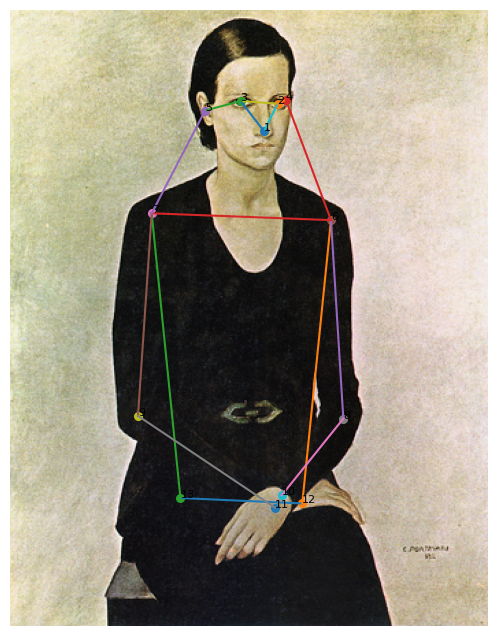

In [4]:
# Displaying one annotated image with its body keypoints and skeleton.
import json, os
import cv2
import matplotlib.pyplot as plt
#import random

ann_path = "/media/chethan/newvolume/ankita/python_project/PoPArt/annotations/person_keypoints_train.json"
img_dir = "/media/chethan/newvolume/ankita/python_project/PoPArt/images/train"

with open(ann_path, "r") as f:
    data = json.load(f)

images = {img["id"]: img for img in data["images"]}
#ann = random.choice(data["annotations"])
ann = data["annotations"][0]

img_info = images[ann["image_id"]]
img_path = os.path.join(img_dir, img_info["file_name"])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

keypoints = ann["keypoints"]
#print('keypoints', keypoints)
#print('keypoints', len(keypoints))
skeleton = data["categories"][0]["skeleton"]

plt.figure(figsize=(8, 8))
plt.imshow(img)

# draw keypoints
for i in range(17):
    x = keypoints[i*3]
    y = keypoints[i*3 + 1]
    v = keypoints[i*3 + 2]

    if v > 0:
        plt.scatter(x, y, s=30)
        plt.text(x, y, str(i+1), fontsize=8)

# draw skeleton
for a, b in skeleton:
    x1, y1, v1 = keypoints[(a-1)*3], keypoints[(a-1)*3+1], keypoints[(a-1)*3+2]
    x2, y2, v2 = keypoints[(b-1)*3], keypoints[(b-1)*3+1], keypoints[(b-1)*3+2]

    if v1 > 0 and v2 > 0:
        plt.plot([x1, x2], [y1, y2])

plt.axis("off")
plt.show()

In [5]:
# Checking how many people are present in each training image.
from collections import Counter

counter = Counter()

for ann in data["annotations"]:
    counter[ann["image_id"]] += 1

print("Images:", len(counter))
print("Max persons in one image:", max(counter.values()))

for n in [1,2,3,4,5]:
    print(f"{n} persons:", sum(v==n for v in counter.values()))

Images: 1472
Max persons in one image: 110
1 persons: 736
2 persons: 228
3 persons: 100
4 persons: 81
5 persons: 36


In [6]:
# Unnescessary but checking the bounding box  and visible key points of 1 image
ann = data["annotations"][0]

print("bbox:", ann["bbox"])
print("num_keypoints:", ann["num_keypoints"])

bbox: [66.0, 6.0, 213.0, 444.0]
num_keypoints: 13


In [7]:
# Displaying all the information of one image
ann = data["annotations"][0]

for k, v in ann.items():
    print(k, ":", v)

id : 2
image_id : 2
category_id : 1
area : 94572
segmentation : [[279.0, 6.0, 279.0, 450.0, 66.0, 450.0, 66.0, 6.0]]
bbox : [66.0, 6.0, 213.0, 444.0]
iscrowd : False
keypoints : [185, 88, 2, 195, 68, 2, 168, 66, 2, 201, 65, 2, 142, 73, 2, 234, 153, 2, 103, 148, 2, 243, 298, 2, 93, 296, 2, 198, 354, 2, 193, 363, 2, 213, 360, 2, 124, 356, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
num_keypoints : 13


In [8]:
visible_counts = []

for ann in data["annotations"]:             #looping
    visible_counts.append(ann.get("num_keypoints", 0))

print("Min visible:", min(visible_counts))      #the smallest number of visible keypoints for any person.
print("Max visible:", max(visible_counts))      #he largest number of visible keypoints for any person.
print("Average visible:", sum(visible_counts) / len(visible_counts))
print("0-keypoint annotations:", sum(k == 0 for k in visible_counts))

Min visible: 0
Max visible: 17
Average visible: 5.010743061772605
0-keypoint annotations: 4410


In [9]:
#print(data.keys())

dict_keys(['info', 'licenses', 'images', 'categories', 'annotations'])


In [10]:
#print(data["annotations"][0].keys())

dict_keys(['id', 'image_id', 'category_id', 'area', 'segmentation', 'bbox', 'iscrowd', 'keypoints', 'num_keypoints'])


In [9]:
#Before training a pose estimation model, it's important to verify that all annotations contain the required information. 
# If some annotations were missing keypoints, training could fail or produce incorrect results.

missing_keypoints = 0
missing_num_keypoints = 0

for ann in data["annotations"]:
    if "keypoints" not in ann:
        missing_keypoints += 1
    if "num_keypoints" not in ann:
        missing_num_keypoints += 1

print("Missing keypoints:", missing_keypoints)
print("Missing num_keypoints:", missing_num_keypoints)
print("Total annotations:", len(data["annotations"]))

Missing keypoints: 4410
Missing num_keypoints: 4410
Total annotations: 6702


In [10]:
'''pose_annotations = [
    ann for ann in data["annotations"]
    if "keypoints" in ann
]

print("Pose annotations:", len(pose_annotations))

Pose annotations: 2292


In [11]:
# Count how many visible keypoints each person has in the dataset.
from collections import Counter

counts = []

for ann in pose_annotations:
    kpts = ann["keypoints"]

    visible = 0
    for i in range(2, len(kpts), 3):
        if kpts[i] > 0:
            visible += 1

    counts.append(visible)

dist = Counter(counts)

for k in sorted(dist):
    print(f"{k:2d} keypoints : {dist[k]}")

 5 keypoints : 21
 6 keypoints : 7
 7 keypoints : 119
 8 keypoints : 27
 9 keypoints : 57
10 keypoints : 37
11 keypoints : 167
12 keypoints : 48
13 keypoints : 237
14 keypoints : 54
15 keypoints : 249
16 keypoints : 55
17 keypoints : 1214


In [12]:
'''# Count how many annotations belong to each object category.
from collections import Counter

cat_counts = Counter()

for ann in pose_annotations:
    cat_counts[ann["category_id"]] += 1

print(cat_counts)

Counter({1: 2292})


In [14]:
# Analyze the image sizes (width and height) in the dataset.
widths = [img["width"] for img in data["images"]]
heights = [img["height"] for img in data["images"]]

print("Min width:", min(widths))
print("Max width:", max(widths))
print("Average width:", sum(widths)/len(widths))

print("Min height:", min(heights))
print("Max height:", max(heights))
print("Average height:", sum(heights)/len(heights))

Min width: 163
Max width: 5536
Average width: 961.5427989130435
Min height: 196
Max height: 5850
Average height: 1107.3627717391305


In [15]:
# Analyze the sizes of person bounding boxes in the dataset.
bbox_widths = [ann["bbox"][2] for ann in pose_annotations]
bbox_heights = [ann["bbox"][3] for ann in pose_annotations]

print("Min bbox width:", min(bbox_widths))
print("Max bbox width:", max(bbox_widths))
print("Average bbox width:", sum(bbox_widths)/len(bbox_widths))

print("Min bbox height:", min(bbox_heights))
print("Max bbox height:", max(bbox_heights))
print("Average bbox height:", sum(bbox_heights)/len(bbox_heights))

Min bbox width: 43.0
Max bbox width: 3537.0
Average bbox width: 448.0082897033159
Min bbox height: 53.0
Max bbox height: 5374.0
Average bbox height: 692.130890052356


img.shape (450, 349, 3)
crop.shape (444, 213, 3)


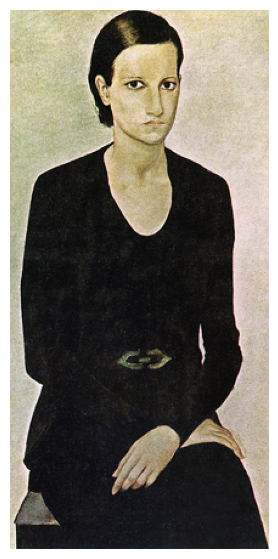

In [18]:
# Crop one person from an image using their bounding box.
import os
import cv2
import matplotlib.pyplot as plt

ann = pose_annotations[0]
img_info = images[ann["image_id"]]

img_path = os.path.join("/media/chethan/newvolume/ankita/python_project/PoPArt/images/train", img_info["file_name"])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x, y, w, h = map(int, ann["bbox"])

print('img.shape', img.shape)

crop = img[y:y+h, x:x+w]

print('crop.shape', crop.shape)

plt.figure(figsize=(5, 7))
plt.imshow(crop)
plt.axis("off")
plt.show()

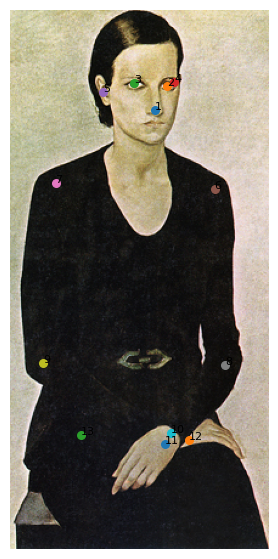

In [19]:
# Show keypoints on the cropped person image.
import matplotlib.pyplot as plt

ann = pose_annotations[0]

x0, y0, w, h = ann["bbox"]
kpts = ann["keypoints"]

plt.figure(figsize=(5,7))
plt.imshow(crop)

for i in range(17):
    x = kpts[i*3]
    y = kpts[i*3+1]
    v = kpts[i*3+2]

    if v > 0:
        plt.scatter(x - x0, y - y0, s=30)
        plt.text(x - x0, y - y0, str(i+1), fontsize=8)

plt.axis("off")
plt.show()

In [20]:
# Create a PyTorch Dataset class to load images, keypoints, and bounding boxes.
import torch
from torch.utils.data import Dataset
import cv2
import os

class PoPArtPoseDataset(Dataset):
    def __init__(self, coco_data, img_dir):
        self.img_dir = img_dir
        self.images = {img["id"]: img for img in coco_data["images"]}
        self.annotations = [
            ann for ann in coco_data["annotations"]
            if "keypoints" in ann and len(ann["keypoints"]) == 51
        ]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_info = self.images[ann["image_id"]]

        img_path = os.path.join(self.img_dir, img_info["file_name"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        keypoints = torch.tensor(ann["keypoints"], dtype=torch.float32).view(17, 3)
        bbox = torch.tensor(ann["bbox"], dtype=torch.float32)

        return img, keypoints, bbox



In [20]:
'''
ann = train_dataset.annotations[0]
img_info = train_dataset.images[ann["image_id"]]

print(img_info["file_name"])

'''

'\nann = train_dataset.annotations[0]\nimg_info = train_dataset.images[ann["image_id"]]\n\nprint(img_info["file_name"])\n\n'

In [21]:
'''import os

target = "candido-portinari_retrato-de-maria-1932.jpg"

for root, dirs, files in os.walk("PoPArt/images"):
    if target in files:
        print("Found in:", root)

In [22]:
'''target = "candido-portinari_retrato-de-maria-1932.jpg"

for root, dirs, files in os.walk("PoPArt/images"):
    if target in files:
        print(root)

In [23]:
'''ann = train_dataset.annotations[0]
img_info = train_dataset.images[ann["image_id"]]

print("Image ID:", ann["image_id"])
print("Filename:", img_info["file_name"])'''

'ann = train_dataset.annotations[0]\nimg_info = train_dataset.images[ann["image_id"]]\n\nprint("Image ID:", ann["image_id"])\nprint("Filename:", img_info["file_name"])'

In [22]:
# Test the custom dataset by loading one sample and checking its outputs.
train_dataset = PoPArtPoseDataset(
    coco_data=data,
    img_dir="images/train"
)

img, keypoints, bbox = train_dataset[0]

print("Image shape:", img.shape)
print("Keypoints shape:", keypoints.shape)
print("BBox:", bbox)
print("BBox.shape:", bbox.shape)

Image shape: (450, 349, 3)
Keypoints shape: torch.Size([17, 3])
BBox: tensor([ 66.,   6., 213., 444.])
BBox.shape: torch.Size([4])


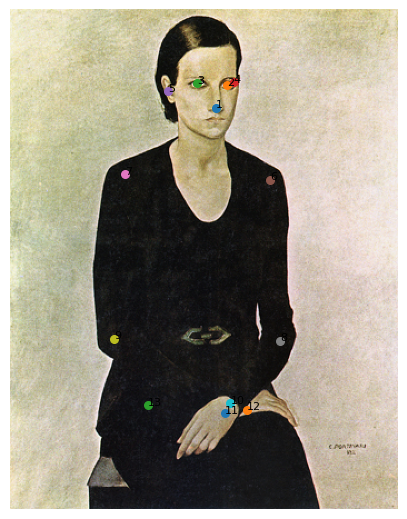

In [25]:
'''plt.figure(figsize=(5,7))
plt.imshow(img)

for i in range(17):
    x, y, v = keypoints[i]
    if v > 0:
        plt.scatter(x, y, s=30)
        plt.text(x, y, str(i+1), fontsize=8)

plt.axis("off")
plt.show()

In [24]:
# Check the PyTorch installation and whether a GPU is available.
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
CUDA available: True
GPU: NVIDIA GeForce GTX 1650 Ti


In [26]:
# Load the pretrained Keypoint R-CNN model for human pose estimation.
import torchvision
from torchvision.models.detection import keypointrcnn_resnet50_fpn

model = keypointrcnn_resnet50_fpn(weights="DEFAULT")

print("Model loaded successfully")

Model loaded successfully


In [27]:
'''class PoPArtKeypointRCNNDataset(Dataset):
    def __init__(self, coco_data, img_dir):
        self.img_dir = img_dir
        self.images = {img["id"]: img for img in coco_data["images"]}
        self.annotations = [
            ann for ann in coco_data["annotations"]
            if "keypoints" in ann and len(ann["keypoints"]) == 51
        ]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_info = self.images[ann["image_id"]]

        img_path = os.path.join(self.img_dir, img_info["file_name"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        x, y, w, h = ann["bbox"]

        target = {}
        target["boxes"] = torch.tensor([[x, y, x + w, y + h]], dtype=torch.float32)
        target["labels"] = torch.tensor([1], dtype=torch.int64)
        target["keypoints"] = torch.tensor(ann["keypoints"], dtype=torch.float32).view(1, 17, 3)
        target["image_id"] = torch.tensor([ann["image_id"]])
        target["area"] = torch.tensor([ann["area"]], dtype=torch.float32)
        target["iscrowd"] = torch.tensor([0], dtype=torch.int64)

        return img, target'''

# Create a custom dataset for training Keypoint R-CNN with resized 256×256 images and scaled annotations.
class PoPArtKeypointRCNN256Dataset(Dataset):
    def __init__(self, coco_data, img_dir, size=256):
        self.img_dir = img_dir
        self.size = size
        self.images = {img["id"]: img for img in coco_data["images"]}
        self.annotations = [
            ann for ann in coco_data["annotations"]
            if "keypoints" in ann and len(ann["keypoints"]) == 51
        ]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_info = self.images[ann["image_id"]]

        img_path = os.path.join(self.img_dir, img_info["file_name"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        old_h, old_w = img.shape[:2]

        scale_x = self.size / old_w
        scale_y = self.size / old_h

        img = cv2.resize(img, (self.size, self.size))
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        x, y, w, h = ann["bbox"]

        x1 = x * scale_x
        y1 = y * scale_y
        x2 = (x + w) * scale_x
        y2 = (y + h) * scale_y

        target = {}
        target["boxes"] = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)
        target["labels"] = torch.tensor([1], dtype=torch.int64)

        keypoints = torch.tensor(ann["keypoints"], dtype=torch.float32).view(1, 17, 3)
        keypoints[:, :, 0] *= scale_x
        keypoints[:, :, 1] *= scale_y

        target["keypoints"] = keypoints
        target["image_id"] = torch.tensor([ann["image_id"]])
        target["area"] = torch.tensor([ann["area"] * scale_x * scale_y], dtype=torch.float32)
        target["iscrowd"] = torch.tensor([0], dtype=torch.int64)

        return img, target


In [28]:
# Test the resized Keypoint R-CNN dataset and verify the image and annotation formats.
train_dataset_256 = PoPArtKeypointRCNN256Dataset(
    coco_data=data,
    img_dir="images/train",
    size=256
)

img, target = train_dataset_256[0]

print("Image:", img.shape)
print("Box:", target["boxes"])
print("Keypoints:", target["keypoints"].shape)
print("Area:", target["area"])

Image: torch.Size([3, 256, 256])
Box: tensor([[ 48.4126,   3.4133, 204.6533, 256.0000]])
Keypoints: torch.Size([1, 17, 3])
Area: tensor([39464.3164])


In [30]:
'''train_dataset = PoPArtKeypointRCNNDataset(
    coco_data=data,
    img_dir="images/train"
)

img, target = train_dataset[0]

print("Image:", img.shape)
print("Boxes:", target["boxes"])
print("Labels:", target["labels"])
print("Keypoints:", target["keypoints"].shape)'''

'train_dataset = PoPArtKeypointRCNNDataset(\n    coco_data=data,\n    img_dir="images/train"\n)\n\nimg, target = train_dataset[0]\n\nprint("Image:", img.shape)\nprint("Boxes:", target["boxes"])\nprint("Labels:", target["labels"])\nprint("Keypoints:", target["keypoints"].shape)'

In [29]:
len(train_dataset_256)

2292

In [30]:
# Create a DataLoader to load batches of images and annotations for training.
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset_256,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

images_batch, targets_batch = next(iter(train_loader))

print(len(images_batch))
print(len(targets_batch))
print(images_batch[0].shape)
print(targets_batch[0].keys())

2
2
torch.Size([3, 256, 256])
dict_keys(['boxes', 'labels', 'keypoints', 'image_id', 'area', 'iscrowd'])


In [31]:
# Run a forward training pass and compute the Keypoint R-CNN training losses.
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = keypointrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)
model.train()

images_batch = [img.to(device) for img in images_batch]
targets_batch = [{k: v.to(device) for k, v in t.items()} for t in targets_batch]

loss_dict = model(images_batch, targets_batch)

print(loss_dict)
print("Total loss:", sum(loss for loss in loss_dict.values()).item())

{'loss_classifier': tensor(0.0844, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1006, device='cuda:0', grad_fn=<DivBackward0>), 'loss_keypoint': tensor(6.5130, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_objectness': tensor(0.0026, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0041, device='cuda:0', grad_fn=<DivBackward0>)}
Total loss: 6.704642295837402


In [34]:
# Run a training forward pass on the GPU and inspect each loss component.(unnessesary)
device = torch.device("cuda")

model = keypointrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)
model.train()

images_batch = [img.to(device) for img in images_batch]
targets_batch = [{k: v.to(device) for k, v in t.items()} for t in targets_batch]

print('len(images_batch)', len(images_batch))

loss_dict = model(images_batch, targets_batch)

for k, v in loss_dict.items():
    print(k, ":", float(v))

print("Total Loss:", float(sum(loss_dict.values())))

len(images_batch) 2
loss_classifier : 0.16782823204994202
loss_box_reg : 0.10296294093132019
loss_keypoint : 5.495445251464844
loss_objectness : 0.018111519515514374
loss_rpn_box_reg : 0.005678700748831034
Total Loss: 5.790026664733887


/tmp/ipykernel_14054/1180279350.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(k, ":", float(v))


## Training starts here
##### Train Keypoint R-CNN on the resized PoPArt dataset and save the trained model.

In [35]:
import torch
import gc
from torch.utils.data import DataLoader
from torchvision.models.detection import keypointrcnn_resnet50_fpn

gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset_256 = PoPArtKeypointRCNN256Dataset(
    coco_data=data,
    img_dir="images/train",
    size=32
)

print('len(train_dataset_256)', len(train_dataset_256))

train_loader_256 = DataLoader(
    train_dataset_256,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

model = keypointrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader_256):
        #print('len(images)', len(images))
        #print('images.shape', images[1].shape)
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 50 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Batch {batch_idx}/{len(train_loader_256)} | "
                f"Loss: {loss.item():.4f} | "
                f"Keypoint Loss: {loss_dict['loss_keypoint'].item():.4f}"
            )

    avg_loss = total_loss / len(train_loader_256)
    print(f"Epoch {epoch+1} finished | Average Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "popart_keypointrcnn_256Next.pth")
print("Model saved as popart_keypointrcnn_256.pth")

len(train_dataset_256) 2292
Epoch 1/3 | Batch 0/1146 | Loss: 8.3512 | Keypoint Loss: 8.0133
Epoch 1/3 | Batch 50/1146 | Loss: 7.9738 | Keypoint Loss: 7.7892
Epoch 1/3 | Batch 100/1146 | Loss: 7.4550 | Keypoint Loss: 7.2034
Epoch 1/3 | Batch 150/1146 | Loss: 6.7112 | Keypoint Loss: 6.4734
Epoch 1/3 | Batch 200/1146 | Loss: 7.8119 | Keypoint Loss: 7.5580
Epoch 1/3 | Batch 250/1146 | Loss: 7.4641 | Keypoint Loss: 7.1421
Epoch 1/3 | Batch 300/1146 | Loss: 6.3890 | Keypoint Loss: 6.1335
Epoch 1/3 | Batch 350/1146 | Loss: 6.1970 | Keypoint Loss: 6.0437
Epoch 1/3 | Batch 400/1146 | Loss: 6.3819 | Keypoint Loss: 6.2031
Epoch 1/3 | Batch 450/1146 | Loss: 7.9387 | Keypoint Loss: 7.7133
Epoch 1/3 | Batch 500/1146 | Loss: 5.7576 | Keypoint Loss: 5.6777
Epoch 1/3 | Batch 550/1146 | Loss: 5.8939 | Keypoint Loss: 5.8116
Epoch 1/3 | Batch 600/1146 | Loss: 6.4466 | Keypoint Loss: 6.3066
Epoch 1/3 | Batch 650/1146 | Loss: 7.7397 | Keypoint Loss: 7.4647
Epoch 1/3 | Batch 700/1146 | Loss: 6.8628 | Keypoin

In [36]:
'''import torch, gc

del model
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared")'''

'import torch, gc\n\ndel model\ngc.collect()\ntorch.cuda.empty_cache()\n\nprint("GPU memory cleared")'